### Importing all Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the Data Set

In [41]:
#reading 
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
#Shape of the data set
df.shape



(7043, 21)

In [43]:
#size of the data set
df.size


147903

In [44]:
#info of the data set
df.info


<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [45]:
#describes the data set
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

No of customers are Churned and not Churned

In [46]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### 1. Data Preprocessing:
   
Handle missing values or incorrect values


In [47]:
# finds the missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

we observed that no missing are present so next check if there is any incorrect values in data



*Fix incorrect values in TotalCharges

->total charges should be in int or float but they are in object means string data type .so we need to change it to the numerical data

In [48]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

Now the data changed to numeric as float data type

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Now check the data if any missing values are present since we converted to numeric data format



In [50]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Fill the missing values using (different methods arer available)

1.Mean

2.Median

3.Using Zero

4.Using back fill ,forward fill methods

In [51]:
#using mean method
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())


Now again check whether null values are gone are not

In [52]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Convert Categorical Columns Using Encoding

->Identify Categorical Columns

In [53]:
#gives the data type of the columns
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [54]:
# prints only categorical columns only
categorical_cols = df.columns[df.dtypes == 'object']
categorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

-> convert the categorical values of the column churn to numeric in case of easy understanding in Ml

   -> Ml only works on numerical values

In [55]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].unique()


array([0, 1])

->customerID is just an identifier.
it does not affect the value of the churn so we can drop it from the data set

In [56]:
#drop the column
df.drop('customerID', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


->So now change the remaining columns like (gender,contract,payment method)also whoes value is in catergorical using encoding

->Encoding converts catergorical value to the  numerical values

In [57]:
categorical_cols = df.columns[df.dtypes == 'object']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = df.astype(int) # this changes the true and false values t0 1,0



here we can obeserve that all are changed to numerical values which is easy in machine learning

In [58]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   SeniorCitizen                          7043 non-null   int64
 1   tenure                                 7043 non-null   int64
 2   MonthlyCharges                         7043 non-null   int64
 3   TotalCharges                           7043 non-null   int64
 4   Churn                                  7043 non-null   int64
 5   gender_Male                            7043 non-null   int64
 6   Partner_Yes                            7043 non-null   int64
 7   Dependents_Yes                         7043 non-null   int64
 8   PhoneService_Yes                       7043 non-null   int64
 9   MultipleLines_No phone service         7043 non-null   int64
 10  MultipleLines_Yes                      7043 non-null   int64
 11  InternetService_Fiber optic   

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


Scale numerical features

in the data set columns like tenture , Monthly Charges,Totalcharges needs scaling

Scaling is required when using KNN,Logistic Regression SVM Etc


Step1: Seperate Feature and Target

In [59]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X[num_cols] = scaler.fit_transform(X[num_cols])


In [61]:
X[num_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,1.250991e-16,-1.056785e-16
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.538551e+00,-9.999974e-01
25%,-9.516817e-01,-9.735900e-01,-8.306695e-01
50%,-1.372744e-01,1.895644e-01,-3.897989e-01
75%,9.214551e-01,8.209910e-01,6.639195e-01
max,1.613701e+00,1.784747e+00,2.826327e+00


### 2. EDA & Insights:
   
    ○ Churn distribution analysis

        -> pie chart

        -> bar chart

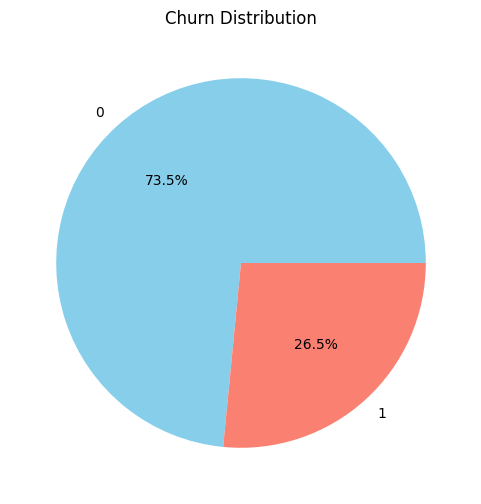

In [62]:
import matplotlib.pyplot as plt
# Churn counts
churn_counts = df['Churn'].value_counts()
# Pie chart with percentages
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title("Churn Distribution")
plt.show()


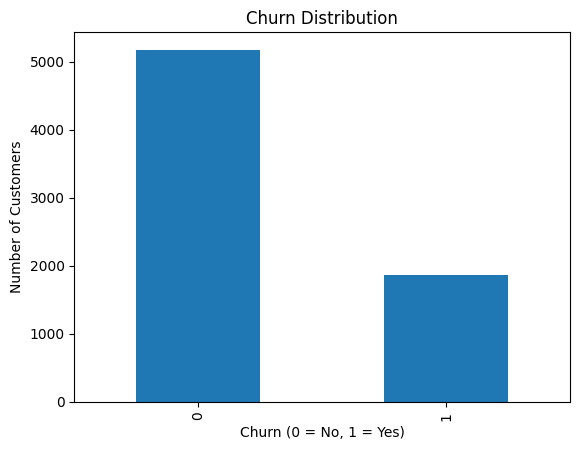

In [63]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()


○ Contract type vs churn rate 

In [64]:
print(df.columns)


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')



Create Contract Type back

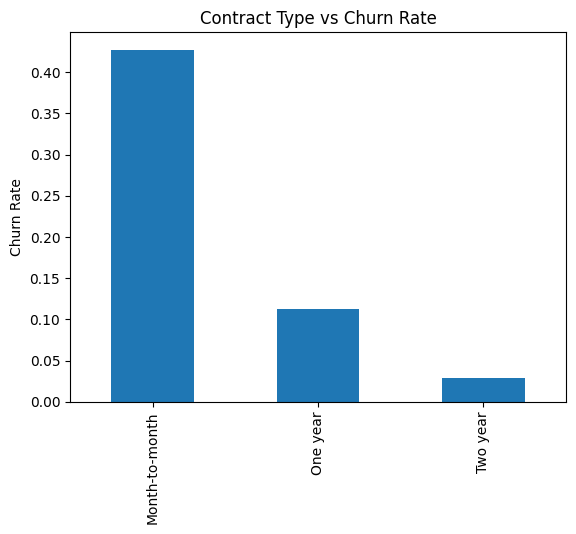

In [65]:
month_churn = df[
    (df['Contract_One year'] == 0) & (df['Contract_Two year'] == 0)
]['Churn'].mean()

one_year_churn = df[df['Contract_One year'] == 1]['Churn'].mean()
two_year_churn = df[df['Contract_Two year'] == 1]['Churn'].mean()

contract_churn = pd.Series(
    [month_churn, one_year_churn, two_year_churn],
    index=['Month-to-month', 'One year', 'Two year']
)

contract_churn.plot(kind='bar')
plt.title("Contract Type vs Churn Rate")
plt.ylabel("Churn Rate")
plt.show()


○ Correlation heatmaps 

Correlation between numerical features and churn.

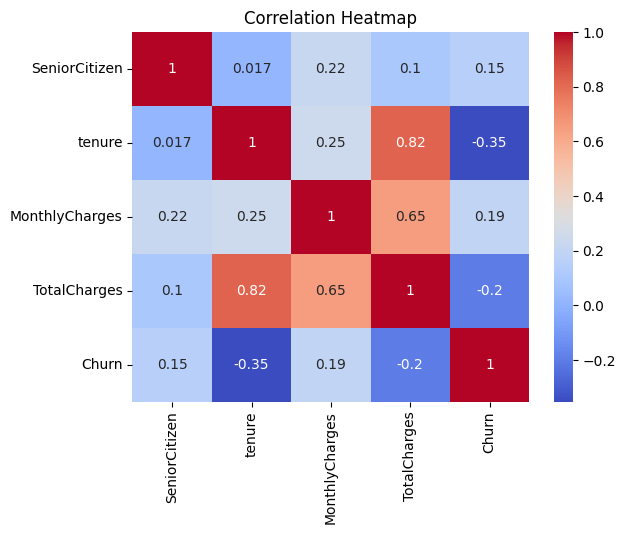

In [66]:
numeric_cols = [
    'SeniorCitizen', 'tenure',
    'MonthlyCharges', 'TotalCharges', 'Churn'
]

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Tenure has strong negative correlation with churn

Customers staying longer are less likely to leave

MonthlyCharges has a mild positive impact on churn

○ Revenue impact of churn 

->How much monthly revenue is lost due to churned customers.

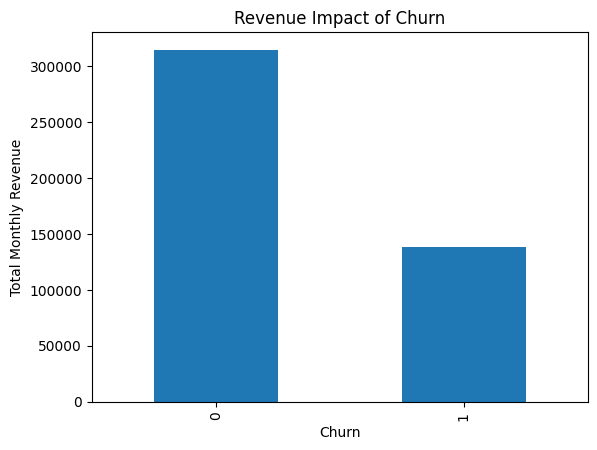

In [67]:
revenue = df.groupby('Churn')['MonthlyCharges'].sum()

revenue.plot(kind='bar')
plt.title("Revenue Impact of Churn")
plt.ylabel("Total Monthly Revenue")
plt.show()


### 3. Modeling: 

-> Prepare data for modeling
                

In [68]:
x=df.drop('Churn',axis=1)
y=df['Churn']

->Train- Test Split

In [69]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

----> Logistic Regression Model

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=5000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)


--->Logistic Regression Model Evalution

In [71]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8211497515968772
[[933 103]
 [149 224]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



--->Decision Tree Classifier

In [72]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)


--->Decision Tree Classifier Evalution

In [73]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7239176721078779
[[853 183]
 [206 167]]
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1036
           1       0.48      0.45      0.46       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



---->Random Forest Classifier

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)


---->Random Forest Classifier Evalution

In [75]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7913413768630234
[[945  91]
 [203 170]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## 4. Final Output

### Top Factors Influencing Customer Churn
- Contract Type: Month-to-month customers show the highest churn.
- Tenure: Customers with shorter tenure are more likely to churn.
- Monthly Charges: Higher charges increase churn probability.
- Payment Method: Electronic check users have higher churn.
- Support Services: Lack of tech support and online security increases churn.

### Recommendations to Reduce Churn
- Encourage long-term contracts through discounts.
- Improve onboarding and engagement for new customers.
- Optimize pricing and offer bundled services.
- Promote automatic payment methods.
- Provide targeted support for high-risk customer segments.


### Deploying the model

In [76]:
import pickle
pickle.dump(lr, open("churn_model.pkl", "wb"))


In [77]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load trained model
model = pickle.load(open("churn_model.pkl", "rb"))

st.title("Customer Churn Prediction System")
st.write("Enter customer details to predict churn")

# --- Collect inputs for all 30 features ---
# Example: I'll show 10 numeric/categorical inputs; fill all 30 based on your dataset
tenure = st.number_input("Tenure", 0, 100)
monthly_charges = st.number_input("Monthly Charges", 0.0, 1000.0)
total_charges = st.number_input("Total Charges", 0.0, 10000.0)

# Example categorical inputs (convert to numeric if needed)
gender = st.selectbox("Gender", ["Male", "Female"])
gender_val = 1 if gender == "Male" else 0

contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
contract_val = [0, 0, 0]  # One-hot encoding
if contract == "Month-to-month":
    contract_val = [1, 0, 0]
elif contract == "One year":
    contract_val = [0, 1, 0]
else:
    contract_val = [0, 0, 1]

# --- Add the remaining features here ---
# For simplicity, you can use default 0 values for unused features
other_features = [0] * 23  # Adjust length to match total 30 features

# --- Combine all features in correct order ---
input_features = [tenure, monthly_charges, total_charges, gender_val] + contract_val + other_features
input_array = np.array(input_features).reshape(1, -1)  # Shape (1,30)

# --- Predict ---
if st.button("Predict"):
    prediction = model.predict(input_array)
    st.write("Prediction:", "Churn" if prediction[0] == 1 else "No Churn")



Overwriting app.py


In [78]:
%%writefile requirements.txt
streamlit
scikit-learn
pandas
numpy


Overwriting requirements.txt
